In [33]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher as dc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

dc.pl.activate_journal_quality()

# Load data

In [35]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.9.4
8.37.0


# simulated data

In [36]:
def visualize_shift_latentt(adata):
    decipher_z = adata.obsm["decipher_z"]
    shift_labels = adata.obs["shift"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
    sc.pl.embedding(adata, basis="decipher_v", color="shift",
                    show=False, ax=axes[0], size=30)
    sc.pl.embedding(adata, basis="decipher_v", color="latent_t",
                    show=False, ax=axes[1], size=30)
    plt.tight_layout()
    plt.show()

In [37]:
def run_pipeline(filepath, shift):
    folder = f"/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Adata/{shift}"
    adata = sc.read_h5ad(f"{folder}/{filepath}")
    adata.uns["color_palette"] = None
    color_palette = None

    decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

    # Train Decipher
    d1, val1 = dc.tl.decipher_train(
        adata, decipher_config, plot_kwargs= {"color": "shift"}, 
        plot_every_k_epochs=5,
    )
    return adata, d1, val1

Epoch 107 (batch 22/22) | | train elbo: 36.69 (last epoch: 36.53) | val ll: 47.79:  11%|█         | 107/1000 [00:23<03:18,  4.51it/s]2026-07-10 16:00:33,271 | INFO : Early stopping has been triggered.
2026-07-10 16:00:33,273 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-10 16:00:33,273 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-10 16:00:33,273 | INFO : Saving decipher model with run_id 2026-07-10-16-00-33-adaptive-olive-chili.


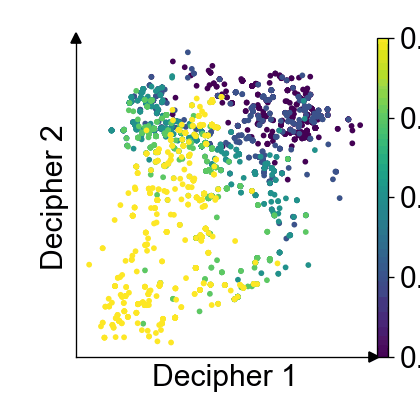

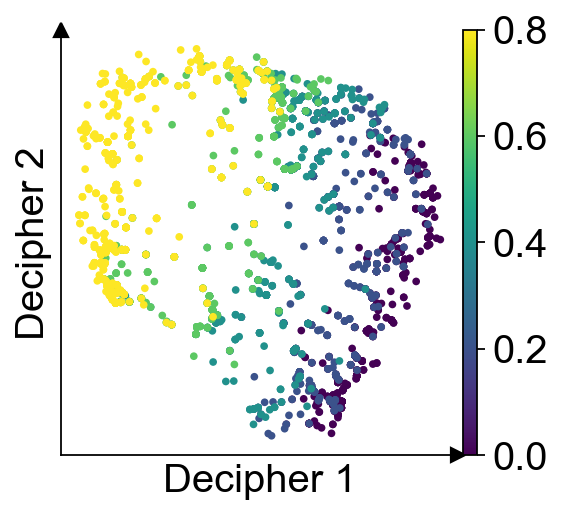

In [38]:
from decipher.tools._decipher import DecipherConfig
adata1, d1, val1 = run_pipeline("0710_vz_0.20_0.40_0.60_0.80.h5ad", "v-to-z")

Epoch 100

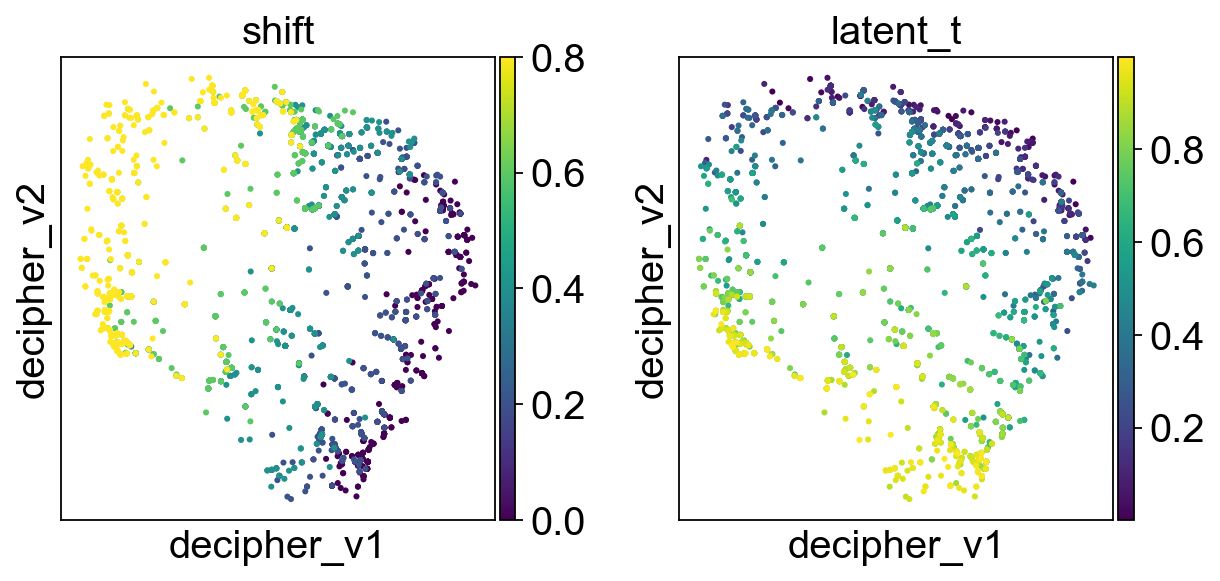

In [39]:
visualize_shift_latentt(adata1)

In [40]:
#Perform Leiden clustering
dc.tl.cell_clusters(adata1, leiden_resolution = 0.05, n_neighbors = 25, seed = 341)
adata1.obs["decipher_clusters"].nunique()

2026-07-10 16:00:33,743 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-10 16:00:33,744 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-10 16:00:33,770 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-10 16:00:34,026 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.


41

In [41]:
# Print number of cells per cluster
adata1.obs['decipher_clusters'].value_counts().sort_index()

#Which cluster does a cell belong to
adata1.obs["decipher_clusters"]

#Ground truth for each cell, or differentiation progress
adata1.obs["latent_t"]

#Group by clusters, and then take average of latent_t
adata1.obs.groupby("decipher_clusters")["latent_t"].mean()

#Group by clusters, take average of latent_t, and then list in ascending order
adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values()

#Group by clusters, take average of latent_t, list in asc. order, and then turn into list
ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()


In [ ]:
# Keep clusters with enough cells. Creates Boolean Series 
filtered_clusters = adata1.obs["decipher_clusters"].value_counts() > 10

# Apply boolean mask --> filtered[filtered] keeps only rows where the mask is True
# Final result is just a python set of the cluster ids with more than 10 cells
filtered_cluster_ids = set(filtered_clusters[filtered_clusters].index)

#Outputs list of cluster IDs, orderd by mean latent_t in ascending order
ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()
# Filters according to filtered cluster id list
ground_truths = [c for c in ground_truths if c in filtered_cluster_ids]

In [43]:
# Computes points that accumulate to form a piecewise linear path through decipher-v space
dc.tl.trajectories(adata1, dc.tl.TConfig("trajectory", cluster_ids_list = ground_truths))

2026-07-10 16:00:34,083 | INFO : Trajectory trajectory : ['27', '4', '26', '0', '29', '16', '30', '21', '2', '31', '20', '34', '25', '28', '9', '11', '1', '10', '6', '14', '12', '32', '17', '22', '5', '15', '18', '8', '19', '7', '24', '13', '23', '3', '33'])
2026-07-10 16:00:34,095 | INFO : Added trajectory trajectory to `adata.uns['decipher']['trajectories']`.


2026-07-10 16:00:34,118 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-10 16:00:34,118 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.


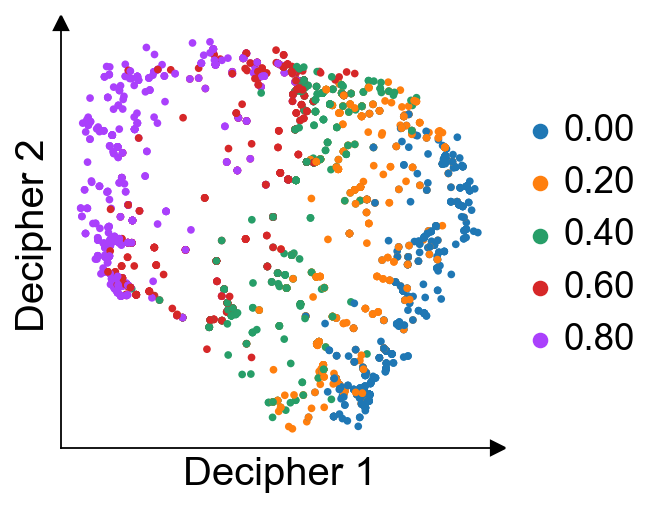

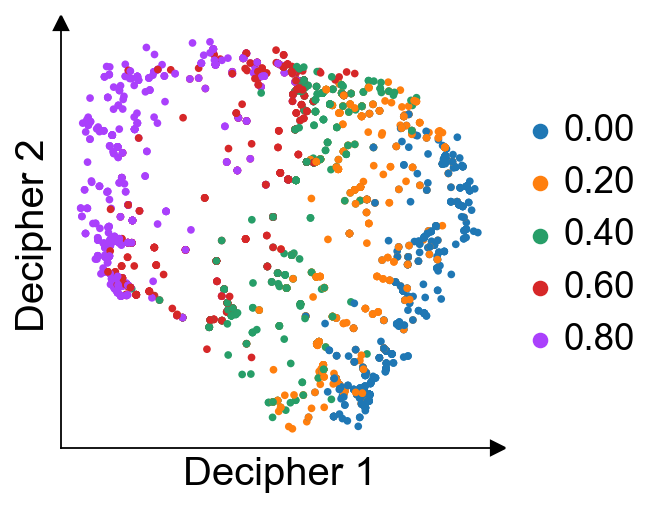

In [44]:
dc.tl.decipher_rotate_space(adata1)
dc.pl.decipher(adata1, color="batch")

In [45]:
dc.tl.decipher_time(adata1)

2026-07-10 16:00:34,234 | INFO : Added `.obs['decipher_time']`: the decipher time of each cell.


In [46]:
# Check that decipher_time was actually populated (not all NaN)
print(adata1.obs["decipher_time"].isna().sum(), "NaN cells")
print(adata1.obs["decipher_time"].describe())

40 NaN cells
count    2460.000000
mean       23.030654
std        16.283596
min         0.090056
25%         7.234496
50%        20.234576
75%        35.632145
max        55.784670
Name: decipher_time, dtype: float64


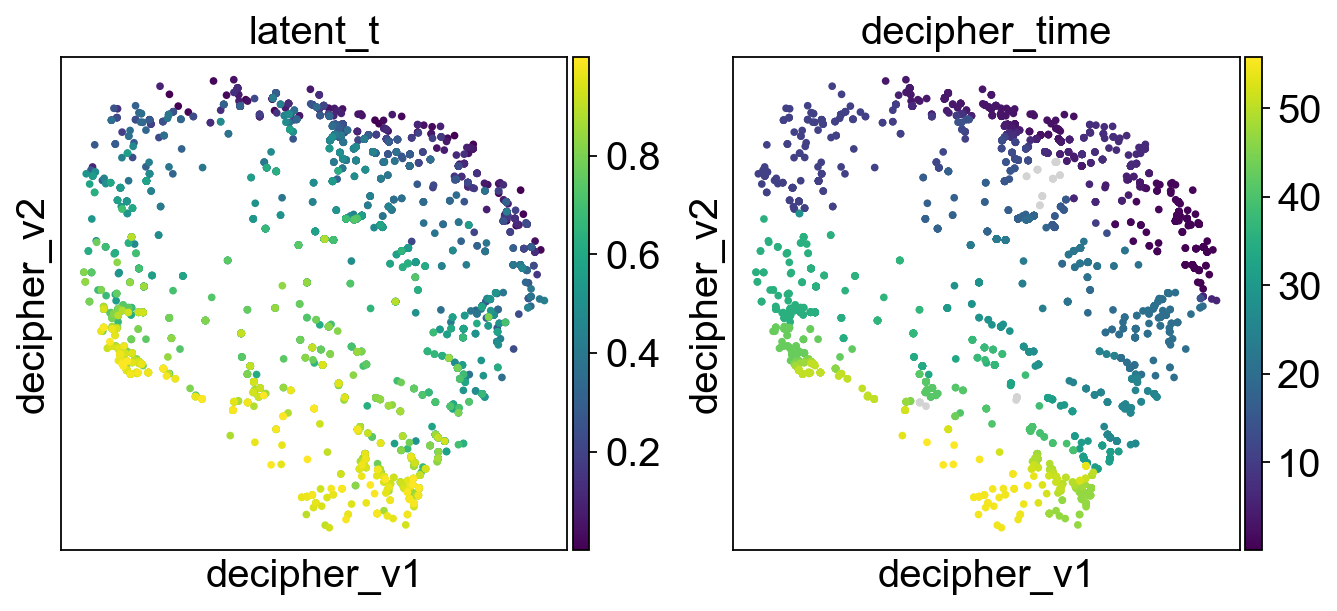

In [47]:
sc.pl.embedding(adata1, basis = "decipher_v", color = ["latent_t", "decipher_time"])

In [48]:
from scipy.stats import spearmanr

for b in sorted(adata1.obs["batch"].unique()):
    mask = adata1.obs["batch"] == b
    # drop NaN cells (those not on trajectory)
    valid = mask & adata1.obs["decipher_time"].notna()
    rho, pval = spearmanr(adata1.obs.loc[valid, "decipher_time"], adata1.obs.loc[valid, "latent_t"])
    print(f"batch={b}  rho={rho:+.4f}  p={pval:.2e}")

batch=0.00  rho=+0.8903  p=6.57e-172
batch=0.20  rho=+0.9021  p=4.73e-178
batch=0.40  rho=+0.9303  p=7.27e-210
batch=0.60  rho=+0.9364  p=1.17e-227
batch=0.80  rho=+0.8869  p=3.64e-169
